<a href="https://colab.research.google.com/github/chanu-24/car-vision-study/blob/main/Day3_Color_Masking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 내가 업로드한 사진[my_yellow_car.jpg]을 불러옵니다...


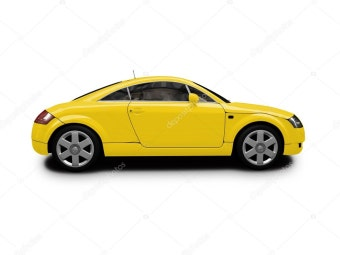


🌈 2. AI의 색안경 교체! (BGR -> HSV)

✂️ 3. '노란색'만 찾아내는 가위(Mask) 만들기
- 흑백 가위질 도안 (흰색 부분이 우리가 오려낼 곳입니다)


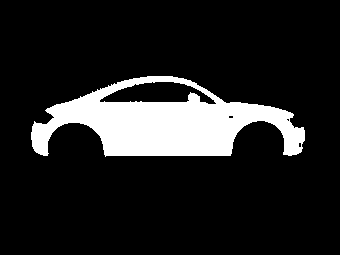


✨ 4. 원본 사진에 가위질 도안(Mask)을 덮어씌워서 노란 부분만 뽑아내기!


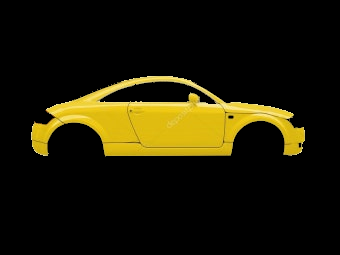


🏆 축하합니다! 내가 직접 고른 노란 차 오려내기 성공!


In [6]:
import cv2
import numpy as np
import urllib.request
import os
from google.colab.patches import cv2_imshow

file_name='my_yellow_car.jpg'

print(f"1. 내가 업로드한 사진[{file_name}]을 불러옵니다...")

#파일이 실제로 있는지 확인하는 개발자의 안전장치

if not os.path.isfile(file_name):
  print(f"❌ 에러! '{file_name}' 파일을 찾을 수 없습니다. 코랩 왼쪽에 파일명과 확장자가 똑같은지 확인해 주세요!")
else:

  img=cv2.imread(file_name)
  cv2_imshow(img)


  print("\n🌈 2. AI의 색안경 교체! (BGR -> HSV)")

  hsv_img=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)


  print("\n✂️ 3. '노란색'만 찾아내는 가위(Mask) 만들기")
  lower_yellow=np.array([15,80,80])
  upper_yellow=np.array([35,255,255])

  # cv2.inRange: 이 숫자 범위 안에 들어오면 하얀색(255), 아니면 검은색(0)으로 칠해라!
  mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)

  # 마스크(정답지)가 어떻게 생겼는지 확인해 볼까요?
  print("- 흑백 가위질 도안 (흰색 부분이 우리가 오려낼 곳입니다)")
  cv2_imshow(mask)

  print("\n✨ 4. 원본 사진에 가위질 도안(Mask)을 덮어씌워서 노란 부분만 뽑아내기!")
    # cv2.bitwise_and: 원본 사진과 원본 사진을 겹치되, mask의 흰색 부분만 통과시켜라!
  result = cv2.bitwise_and(img, img, mask=mask)
  cv2_imshow(result)

  print("\n🏆 축하합니다! 내가 직접 고른 노란 차 오려내기 성공!")

예를 들면 자율주랭 자동차가 도로 위에서 '노란색 차선'이나 '빨간색
브레이크 등'을 귀신같이 찾아내는 마법->특정 색상만 추출하기

RGB 색상표에는 치명적인 단점이 있다. 빛조명에 너무 약하다.


그래서 RGB 대신 HSV를 쓴다,

(H:색상):빨강,노랑,파랑 같은 '진짜 색깔'의 종류
(S:채도):색의 탁하고 선명한 정도
(V:명도):색의 밝기